<a href="https://colab.research.google.com/github/1Akash3/spendsmart-ml/blob/main/SpendSmart_Recommender_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💸 SpendSmart‑ML — Personalized Spending Recommender (Colab)

Standalone model‑training notebook for a **personalized** (per‑user, not generic) spending
recommendation engine, with **benchmarked accuracy** and a **real‑time** update demo.

**Run order:** Runtime → Run all. Everything is CPU‑only and finishes in a few minutes.

Pipeline: `categorizer → monthly panel → cohorts → personalized forecaster → recommender`.

## 1 · Setup — get the code + install deps

In [1]:
# Option A: clone from GitHub, OR
# Option B: upload the `spendsmart-ml` folder via the Files panel and skip the clone.
import os, sys

REPO_URL = 'https://github.com/1Akash3/spendsmart-ml.git'
PROJECT_DIR = 'spendsmart-ml'

if REPO_URL and not os.path.isdir(PROJECT_DIR):
    !git clone -q $REPO_URL

# Fallback: if you uploaded files to /content directly, point PROJECT_DIR at them.
if not os.path.isdir(PROJECT_DIR):
    PROJECT_DIR = '.' if os.path.isfile('config.py') else PROJECT_DIR

assert os.path.isdir(PROJECT_DIR), (
    'Upload the spendsmart-ml folder or set REPO_URL. '
    'Expected to find config.py inside PROJECT_DIR.')
os.chdir(PROJECT_DIR)
print('Working dir:', os.getcwd())

Working dir: /content/spendsmart-ml


In [2]:
!pip -q install -r requirements.txt
import os, sys; sys.path.insert(0, os.getcwd()); sys.path.insert(0, os.path.join(os.getcwd(),'src'))

### Kaggle auth — using Colab **Secrets**, not hardcoded values

This notebook lives in a **public** GitHub repo, so credentials never get typed into any cell here.

1. Click the **key icon (🔑)** in the left sidebar of Colab → **Secrets**.
2. Add two secrets: `KAGGLE_USERNAME` and `KAGGLE_KEY` (values from kaggle.com/settings → *Create New Token*).
3. Toggle **"Notebook access"** on for both.
4. Run the cell below — it reads them from Secrets into the environment for this session only. Nothing is written to disk or to the repo.

In [3]:
from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
print('Kaggle credentials loaded from Colab Secrets for this session.')

# Before this works, visit each dataset page on kaggle.com and click
# "I Understand and Accept" if prompted — a valid token alone isn't always enough.
#   https://www.kaggle.com/datasets/priyamchoksi/credit-card-transactions-dataset
#   https://www.kaggle.com/datasets/khushikyad001/personal-finance-tracker-dataset

Kaggle credentials loaded from Colab Secrets for this session.


### Persist artifacts + reports to Drive

Colab VMs are wiped when the session ends — run this before/after training so `artifacts/` and `reports/` survive.

In [4]:
from google.colab import drive
drive.mount('/content/drive')
DRIVE_OUT = '/content/drive/MyDrive/spendsmart-ml-outputs'
import os
os.makedirs(DRIVE_OUT, exist_ok=True)
print('Will copy artifacts/reports to:', DRIVE_OUT)

Mounted at /content/drive
Will copy artifacts/reports to: /content/drive/MyDrive/spendsmart-ml-outputs


## 2 · Train the whole pipeline

Loads **real** transactions (Kaggle credit-card dataset, ~1.3M rows, 983 users, 18 months),
trains every stage, and back-tests accuracy against naive baselines. Pass `source="synthetic"`
for an offline, no-credentials run.

In [5]:
from src.train import run
# COMBINED real data by default (credit-card + personal-finance-tracker). Needs a Kaggle token.
metrics = run(source="combined", demo_goal_rate=0.25, seed=42)
# credit-card only:  run(source="real")   |   offline:  run(source="synthetic", users=500, months=18)

[10:53:26] Loading ALL REAL data (credit-card + personal-finance-tracker) …


100%|██████████| 145M/145M [00:07<00:00, 19.5MB/s]

Extracting files...


100%|██████████| 169k/169k [00:00<00:00, 416kB/s]

Extracting files...


...

100%|██████████| 34.1k/34.1k [00:00<00:00, 2.06MB/s]

Extracting files...


100%|██████████| 292k/292k [00:00<00:00, 459kB/s]

Extracting files...


[10:54:35]   1,308,352 transactions, 1927 users, 11 categories  [source=combined]
[10:54:35] Training transaction categorizer (TF-IDF word+char → logistic regression) …
[10:54:49]   accuracy=0.910  macro_f1=0.906
[10:54:49] Building monthly panel + user profiles …
[10:54:59]   panel rows=42,287  users profiled=1927
[10:54:59] Segmenting users into 6 cohorts (KMeans) …
[10:54:59]   silhouette=0.230
[10:54:59] Back-testing personalized forecaster (train past → predict held-out months) …
[10:55:23]   MAE model=271.25 vs naive=291.43 | skill_vs_naive=0.0692
[10:55:23] Evaluating overspend detector (recommendation quality) …
[10:55:46]   overspend F1 model=0.4325 vs naive=0.2373
[10:55:46] Fitting final forecaster on full history …
[10:56:14] Saving artifacts + metrics …

                              RESULTS SUMMARY                             
  Categorizer     accuracy=0.910  macro-F1=0.906
  Segmentation    6 cohorts  silhouette=0.230
  Forecaster      MAE=271.25  (naive=291.43)  WAPE=0

Run this **after** training (Section 2) completes, to copy the results out:

In [6]:
!cp -r artifacts reports "$DRIVE_OUT"/
print('Copied to Drive:', DRIVE_OUT)

Copied to Drive: /content/drive/MyDrive/spendsmart-ml-outputs


## 3 · Proven accuracy (vs naive baselines)

In [7]:
import json
c, f = metrics['categorizer'], metrics['forecaster']
r = metrics.get('recommender_eval', {})
print(f"Categorizer   : accuracy={c['accuracy']:.3f}  macro-F1={c['macro_f1']:.3f}")
print(f"Forecaster    : MAE={f['model_mae']} vs naive={f['naive_mae']}  "
      f"(skill {f['skill_vs_naive']:+.1%})")
if 'model' in r:
    print(f"Overspend det.: F1={r['model']['f1']} vs naive F1={r['naive_baseline']['f1']}")
print(f"Segmentation  : silhouette={metrics['segmentation']['silhouette']:.3f}")

Categorizer   : accuracy=0.910  macro-F1=0.906
Forecaster    : MAE=271.25 vs naive=291.43  (skill +6.9%)
Overspend det.: F1=0.4325 vs naive F1=0.2373
Segmentation  : silhouette=0.230


### Forecaster MAE by category — model vs naive

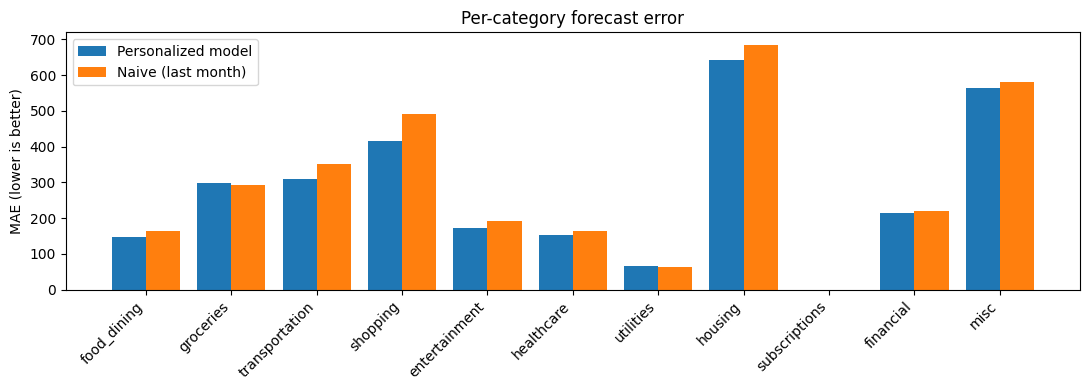

In [8]:
import matplotlib.pyplot as plt
import numpy as np
pc = metrics['forecaster']['per_category_mae']
cats = list(pc.keys())
model = [pc[c]['model_mae'] for c in cats]
naive = [pc[c]['naive_mae'] for c in cats]
x = np.arange(len(cats)); w = 0.4
fig, ax = plt.subplots(figsize=(11,4))
ax.bar(x-w/2, model, w, label='Personalized model')
ax.bar(x+w/2, naive, w, label='Naive (last month)')
ax.set_xticks(x); ax.set_xticklabels(cats, rotation=45, ha='right')
ax.set_ylabel('MAE (lower is better)'); ax.set_title('Per-category forecast error')
ax.legend(); plt.tight_layout(); plt.show()

## 4 · A single user's personalized recommendation

Rebuild the artifacts in‑notebook so we can inspect one user end‑to‑end.

In [10]:
import numpy as np
from data_sources import load_real_transactions
from features import (build_monthly_panel, build_user_profiles, build_forecast_frame,
                      build_serving_frame, PROFILE_FEATURE_COLS)
from segmentation import UserSegmenter
from forecaster import PersonalizedForecaster
from recommender import PersonalizedRecommender, RealTimeState
from config import EXPENSE_CATEGORIES, CATEGORY_LABELS

df = load_real_transactions()              # REAL Kaggle transactions
panel = build_monthly_panel(df)
panel['income'] = panel['income'].fillna(0.0)
profiles = build_user_profiles(panel).replace([np.inf, -np.inf], np.nan).fillna(0.0)
seg = UserSegmenter().fit(profiles)
static = seg.assign(profiles)[PROFILE_FEATURE_COLS + ['cohort']].reset_index()
fc = PersonalizedForecaster().fit(build_forecast_frame(panel, static_features=static))
forecasts = fc.predict_by_user_category(build_serving_frame(panel, static_features=static))
print('Artifacts ready for', len(forecasts), 'real users')

Using Colab cache for faster access to the 'credit-card-transactions-dataset' dataset.
Artifacts ready for 908 real users


In [11]:
USER = int(profiles.index[5])   # pick any user id
upanel = panel[panel.user_id == USER]
cohort = int(static.loc[static.user_id == USER, 'cohort'].iloc[0])
out = PersonalizedRecommender().recommend(
    upanel, forecasts[USER], cohort_norms_row=seg.cohort_category_norms_.loc[cohort],
    savings_goal_rate=0.30)

s = out['summary']
print(f"User {USER} | cohort {cohort} | income≈₹{s['avg_income']:,.0f} | "
      f"projected savings rate {s['projected_savings_rate']*100:.1f}%\n")
for i, rec in enumerate(out['recommendations'], 1):
    print(f"{i}. [{rec['kind']}] {rec['title']}")
    print(f"   {rec['detail']}")
    print(f"   ~₹{rec['monthly_impact']:,.0f}/mo  (confidence {rec['confidence']:.0%})\n")
if out['plan']:
    print('Savings plan:', out['plan']['summary'])

User 60490596305 | cohort 2 | income≈₹4,494 | projected savings rate -9.8%

1. [reallocation] Plan to hit a 30% savings goal
   Cutting Miscellaneous −₹481, Shopping −₹422, Entertainment −₹102, Food & Dining −₹73 recovers ₹1,077/mo, but the goal needs ₹1,790 — consider a gentler target or boosting income.
   ~₹1,077/mo  (confidence 90%)

2. [overspend] Shopping trending above your usual
   Projected ₹1,146 next month vs your typical ₹455 (1.8σ high). Trimming here saves ~₹692.
   ~₹692/mo  (confidence 61%)

3. [overspend] Transportation trending above your usual
   Projected ₹856 next month vs your typical ₹462 (2.9σ high). Trimming here saves ~₹394.
   ~₹394/mo  (confidence 95%)

4. [peer] Shopping is high for users like you
   You put 23% of spend here vs 15% for your cohort. Aligning frees ~₹390/mo.
   ~₹390/mo  (confidence 70%)

5. [overspend] Miscellaneous trending above your usual
   Projected ₹1,203 next month vs your typical ₹707 (0.9σ high). Trimming here saves ~₹496.
   ~₹496

### That user's spending history + next‑month forecast

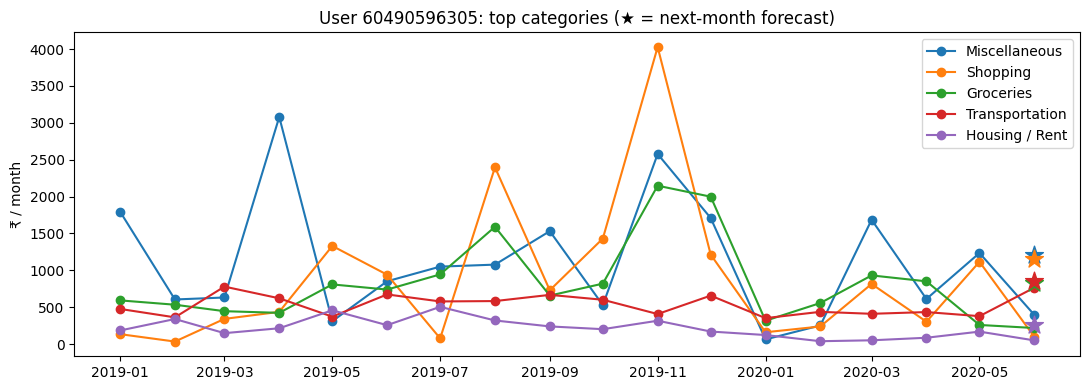

In [12]:
import matplotlib.pyplot as plt
g = upanel.sort_values('month')
top = g[EXPENSE_CATEGORIES].mean().sort_values(ascending=False).head(5).index.tolist()
fig, ax = plt.subplots(figsize=(11,4))
for c in top:
    ax.plot(g['month'], g[c], marker='o', label=CATEGORY_LABELS[c])
    ax.scatter([g['month'].max()], [forecasts[USER][c]], marker='*', s=180, zorder=5)
ax.set_title(f'User {USER}: top categories (★ = next-month forecast)')
ax.set_ylabel('₹ / month'); ax.legend(); plt.tight_layout(); plt.show()

## 5 · Real‑time optimization demo

Feed transactions as they 'arrive' mid‑month; the online layer projects the
month‑end total and fires an alert in O(#categories) — no retrain.

In [13]:
mean = {c: float(upanel[c].mean()) for c in EXPENSE_CATEGORIES}
std  = {c: float(upanel[c].std(ddof=0)) for c in EXPENSE_CATEGORIES}
rt = RealTimeState(mean, std, income=float(upanel['income'].mean()))

# Simulate a heavy dining week early in the month.
stream = [('food_dining', mean['food_dining']*0.5, 3),
          ('food_dining', mean['food_dining']*0.6, 6),
          ('shopping',    mean['shopping']*0.4,   7),
          ('food_dining', mean['food_dining']*0.7, 9)]
for cat, amt, day in stream:
    for a in rt.update(cat, amt, day):
        print(f"day {day:>2}  ⚠  {a['message']}")
print('\nProjected month-end (top 5):')
pe = rt.projected_month_end()
for c in sorted(pe, key=pe.get, reverse=True)[:5]:
    print(f"  {CATEGORY_LABELS[c]:<16} ₹{pe[c]:,.0f}")

day  3  ⚠  On pace for ₹766 in Food & Dining this month — above your usual ₹153.
day  6  ⚠  On pace for ₹843 in Food & Dining this month — above your usual ₹153.
day  9  ⚠  On pace for ₹919 in Food & Dining this month — above your usual ₹153.

Projected month-end (top 5):
  Shopping         ₹1,171
  Food & Dining    ₹919
  Groceries        ₹0
  Transportation   ₹0
  Entertainment    ₹0


## 6 · (Optional) Train on REAL public datasets

Pull the 4.5M‑row HuggingFace categorization set (MIT) or Kaggle sets. Needs
`datasets` / `kagglehub` + credentials. See `data/README.md` for the full catalog.

In [14]:
!pip -q install datasets
# Our registry lives in src/data_sources.py (named to NOT clash with HF's `datasets`).
from data_sources import REGISTRY, print_catalog
print_catalog()

# HF token from Colab Secrets (add HF_TOKEN there first: key icon -> Secrets).
# Same reasoning as Kaggle above -- this repo is public, so no token is typed here.
from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get('HF_TOKEN'))

from data_sources import load_hf_transaction_categorization
real = load_hf_transaction_categorization(sample=100_000)   # 4.5M-row MIT set, sampled
from categorizer import TransactionCategorizer
from sklearn.model_selection import train_test_split
Xtr,Xte,ytr,yte = train_test_split(real['description'], real['category'], test_size=0.2)
print(TransactionCategorizer().fit(Xtr,ytr).evaluate(Xte,yte))

key                   name                                  rows      license       use
----------------------------------------------------------------------------------------------------
hf_txn_cat            Transaction Categorization            ~4.5M     MIT           categorizer
kaggle_expense_cls    Personal Expense Classification       synthetic Kaggle terms  categorizer
kaggle_finance_trackerPersonal Finance Tracker              ~3k users Kaggle terms  personalization
kaggle_expenses_incomeFinancial Transactions (Expenses & Income)—         Kaggle terms  panel
kaggle_credit_card    Credit Card Transactions              ~1.85M    Kaggle terms  behavior/segmentation


README.md:   0%|          | 0.00/11.0k [00:00<?, ?B/s]

default/train/0000.parquet: reconstructing file:   0%|          |  0.00B / 71.0MB            

default/train/0000.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/4501043 [00:00<?, ? examples/s]

{'accuracy': 0.9866, 'macro_f1': 0.9862608598086852, 'weighted_f1': 0.9866092791955169, 'n_test': 20000, 'report': {'entertainment': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 2018.0}, 'financial': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 1959.0}, 'food_dining': {'precision': 0.9917990773962071, 'recall': 0.9948586118251928, 'f1-score': 0.9933264887063655, 'support': 1945.0}, 'healthcare': {'precision': 0.9598236158745713, 'recall': 0.9790104947526237, 'f1-score': 0.9693221177634834, 'support': 2001.0}, 'income': {'precision': 0.9886363636363636, 'recall': 0.9930521091811414, 'f1-score': 0.9908393166625402, 'support': 2015.0}, 'misc': {'precision': 0.9949710837314558, 'recall': 0.9838388861263053, 'f1-score': 0.9893736717089636, 'support': 4022.0}, 'shopping': {'precision': 0.9521384928716904, 'recall': 0.9473150962512664, 'f1-score': 0.9497206703910615, 'support': 1974.0}, 'transportation': {'precision': 0.9951243295953194, 'recall': 0.988856589

---
Everything here is decoupled from the SpendSmart web app — this notebook only
trains and evaluates the model. Integration is a separate, later step.